Project 02 - Heart Disease Prediction using Machine Learning

In [1]:
!pip install kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split

plt.style.use('default')

In [2]:
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 6.18k/6.18k [00:00<00:00, 10.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/johnsmith88/heart-disease-dataset/versions/2
['heart.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "heart.csv"))

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1025, 14)


In [5]:
print("Data Types:")
print(df.dtypes)

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
723


In [8]:
print("Shape before:", df.shape)

print("Duplicate rows:", df.duplicated().sum())

Shape before: (1025, 14)
Duplicate rows: 723


In [9]:
df.drop_duplicates(inplace=True)

print("Shape after:", df.shape)

Shape after: (302, 14)


The dataset contained 723 duplicate records. Duplicate rows were removed to prevent the machine learning models from learning the same observations multiple times, which could bias the results and reduce model generalization. After removing duplicates, the dataset became cleaner and more suitable for analysis and model training.Now I got 302 rows

In [10]:
print(df.shape)
print(df['target'].value_counts())

(302, 14)
target
1    164
0    138
Name: count, dtype: int64


In [11]:
corr_target = df.corr()['target'].sort_values(ascending=False)

print(corr_target)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


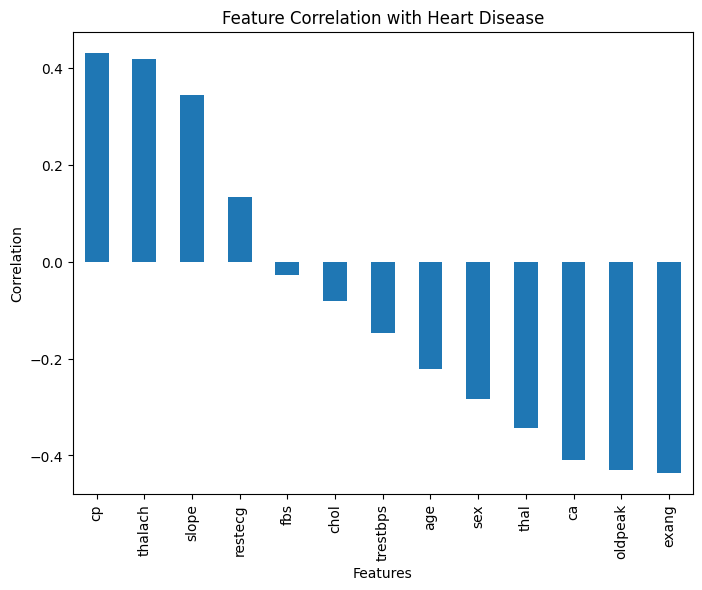

In [15]:
plt.figure(figsize=(8,6))

corr_target.drop('target').plot(kind='bar')

plt.title('Feature Correlation with Heart Disease')
plt.xlabel('Features')
plt.ylabel('Correlation')

plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_temp = RandomForestClassifier(random_state=42)

rf_temp.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
7    thalach    0.134202
2         cp    0.128033
9    oldpeak    0.115018
11        ca    0.108043
12      thal    0.099852
0        age    0.090054
4       chol    0.074063
3   trestbps    0.071019
8      exang    0.060830
10     slope    0.051134
1        sex    0.038703
6    restecg    0.021519
5        fbs    0.007529


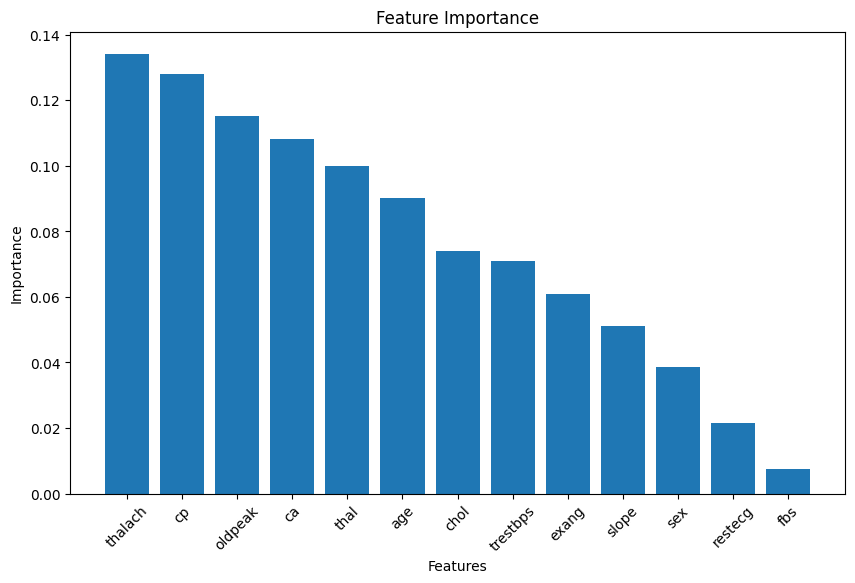

In [17]:
plt.figure(figsize=(10,6))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.xticks(rotation=45)

plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [19]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [29]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Feature scaling was performed using StandardScaler to normalize the numerical features. This helps distance-based algorithms such as KNN and optimization-based algorithms such as Logistic Regression perform more effectively and converge faster during training.

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [34]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.786885,0.722222,0.896552,0.800000
1,KNN,0.737705,0.696970,0.793103,0.741935
2,Random Forest,0.836066,0.787879,0.896552,0.838710


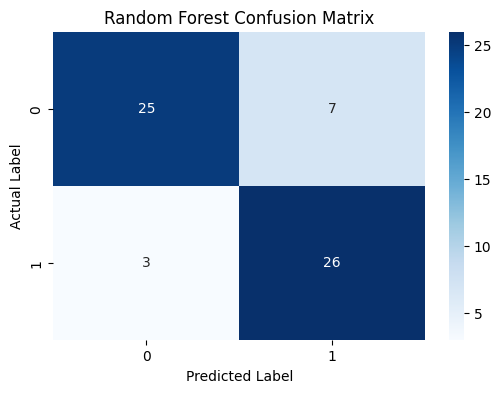

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

The Heart Disease dataset was successfully preprocessed and analyzed before training machine learning models.

Three classification algorithms—Logistic Regression, K-Nearest Neighbors, and Random Forest—were trained and evaluated using Accuracy, Precision, Recall, and F1 Score.

Among all models, Random Forest achieved the highest accuracy of 83.61% and the best overall performance across evaluation metrics.

The confusion matrix confirmed that Random Forest made the fewest prediction errors and generalized effectively on unseen test data.

Therefore, Random Forest was selected as the final model because it provided the most reliable and accurate heart disease predictions.


Feature engineering was performed using correlation analysis and feature importance evaluation. The relationships between features and the target variable were examined using a correlation heatmap. Feature importance obtained from the Random Forest model helped identify the most influential variables for prediction. Since all features contributed meaningful information, no feature was removed from the final model.
